<a href="https://colab.research.google.com/github/alyasirharahap/AGDO-MT-Inversion/blob/main/AGDO_MT_Inversion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **AGDO ALGORITHM (SYNTHETIC DATA)**

The synthetic data has been successfully saved: Data_Synthetic_Model_2.txt


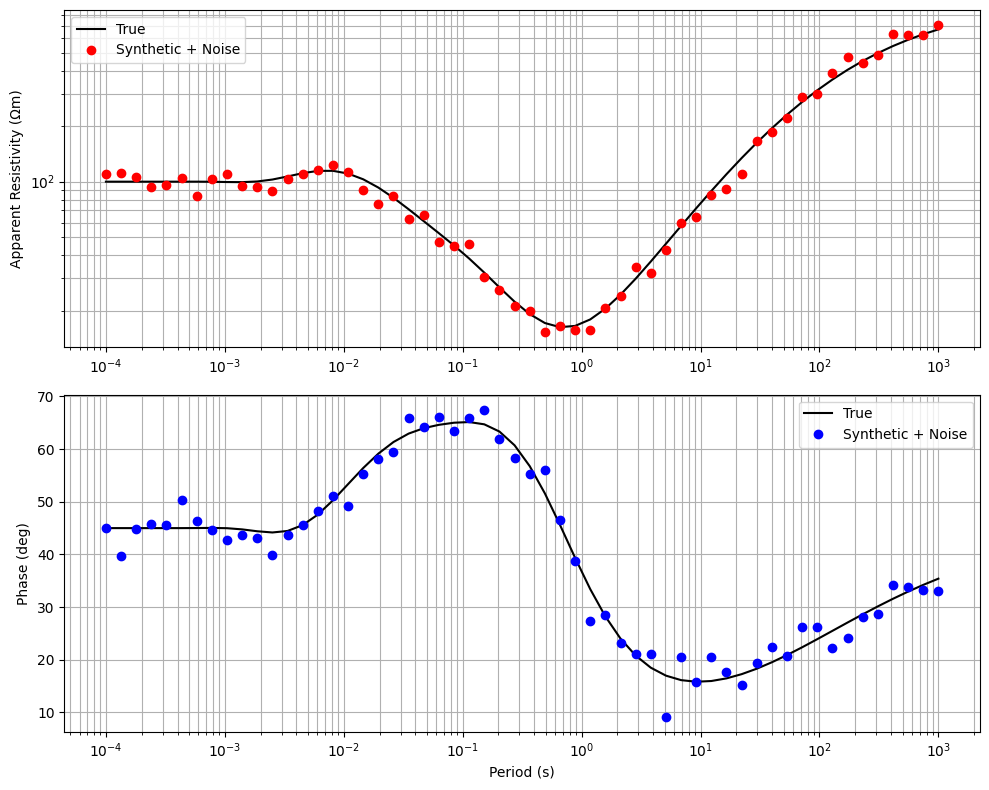

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Forward Modelling MT 1D (Recursive Impedance)
def MT1D(resistivities, thicknesses, frequency):
    mu0 = 4 * np.pi * 1e-7
    omega = 2 * np.pi * frequency
    nlayer = len(resistivities)

    Z = np.zeros(len(frequency), dtype=complex)

    for i, w in enumerate(omega):
        # Start from half-space
        Zj = np.sqrt(1j * w * mu0 * resistivities[-1])

        # Recursive upward calculation
        for j in range(nlayer - 2, -1, -1):
            rho = resistivities[j]
            h = thicknesses[j]

            kj = np.sqrt(1j * w * mu0 / rho)
            Z0 = np.sqrt(1j * w * mu0 * rho)

            r = (Zj - Z0) / (Zj + Z0)
            Zj = Z0 * (1 + r * np.exp(-2 * kj * h)) / (1 - r * np.exp(-2 * kj * h))

        Z[i] = Zj

    return Z

# Model Selection
Modelname = '2'  # choose model: '1' atau '2'

if Modelname == '1':
    resistivity = np.array([100, 1000, 10])   # Ohm.m
    thickness   = np.array([500, 1000])       # meter
elif Modelname == '2':
    resistivity = np.array([100, 10, 1000])
    thickness   = np.array([500, 1000])


# Frequency Setup
ndata = 56
freq = np.logspace(-3, 4, ndata)  # Hz

# Forward Modelling
Z_syn = MT1D(resistivity, thickness, freq)


# Apparent Resistivity & Phase (True)
mu0 = 4 * np.pi * 1e-7
omega = 2 * np.pi * freq

rho_app = (np.abs(Z_syn)**2) / (mu0 * omega)
phase = np.degrees(np.angle(Z_syn))

# Add Gaussian Noise (CONSISTENT COMPLEX NOISE)
np.random.seed(42)        # reproducibility
noise_level = 0.05       # 5%

Z_noise = Z_syn * (1 + noise_level * np.random.randn(len(Z_syn))) \
          + 1j * Z_syn * (noise_level * np.random.randn(len(Z_syn)))

rho_app_noise = (np.abs(Z_noise)**2) / (mu0 * omega)
phase_noise = np.degrees(np.angle(Z_noise))

# Save Synthetic Data
data = np.column_stack((freq, rho_app_noise, phase_noise))

filename = f"Data_Synthetic_Model_{Modelname}.txt"
np.savetxt(
    filename,
    data,
    header="Frequency(Hz)\tApparentResistivity(Ohm.m)\tPhase(deg)",
    comments=''
)

print(f"The synthetic data has been successfully saved: {filename}")

# Plot Synthetic Data
plt.figure(figsize=(10,8))

# Apparent Resistivity
plt.subplot(2,1,1)
plt.loglog(1/freq, rho_app, '-k', label='True')
plt.loglog(1/freq, rho_app_noise, 'or', label='Synthetic + Noise')
plt.ylabel('Apparent Resistivity (Ωm)')
plt.legend()
plt.grid(True, which='both')

# Phase
plt.subplot(2,1,2)
plt.semilogx(1/freq, phase, '-k', label='True')
plt.semilogx(1/freq, phase_noise, 'ob', label='Synthetic + Noise')
plt.xlabel('Period (s)')
plt.ylabel('Phase (deg)')
plt.legend()
plt.grid(True, which='both')

plt.tight_layout()
plt.show()

<>:283: SyntaxWarning: invalid escape sequence '\O'
<>:283: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_1095/2442262770.py:283: SyntaxWarning: invalid escape sequence '\O'
  plt.xlabel('Resistivity ($\Omega$.m)',


Synthetic MT data loaded
Total frequencies: 56

Starting AGDO inversion...

Iteration 10 | Best Misfit = 9.6051
Iteration 20 | Best Misfit = 6.8908
Iteration 30 | Best Misfit = 6.0713
Iteration 40 | Best Misfit = 6.0490
Iteration 50 | Best Misfit = 6.0382
Iteration 60 | Best Misfit = 6.0231
Iteration 70 | Best Misfit = 6.0007
Iteration 80 | Best Misfit = 5.9977
Iteration 90 | Best Misfit = 5.9967

Convergence criterion reached
Stopped at iteration 98
Best Misfit = 5.9966

=========== FINAL RESULT ===========
Resistivity (Ohm.m): [  98.13826981    9.61812681 1037.87506561]
Thickness (m): [497.06557712 982.27013362]
Final Misfit: 5.996592420153143


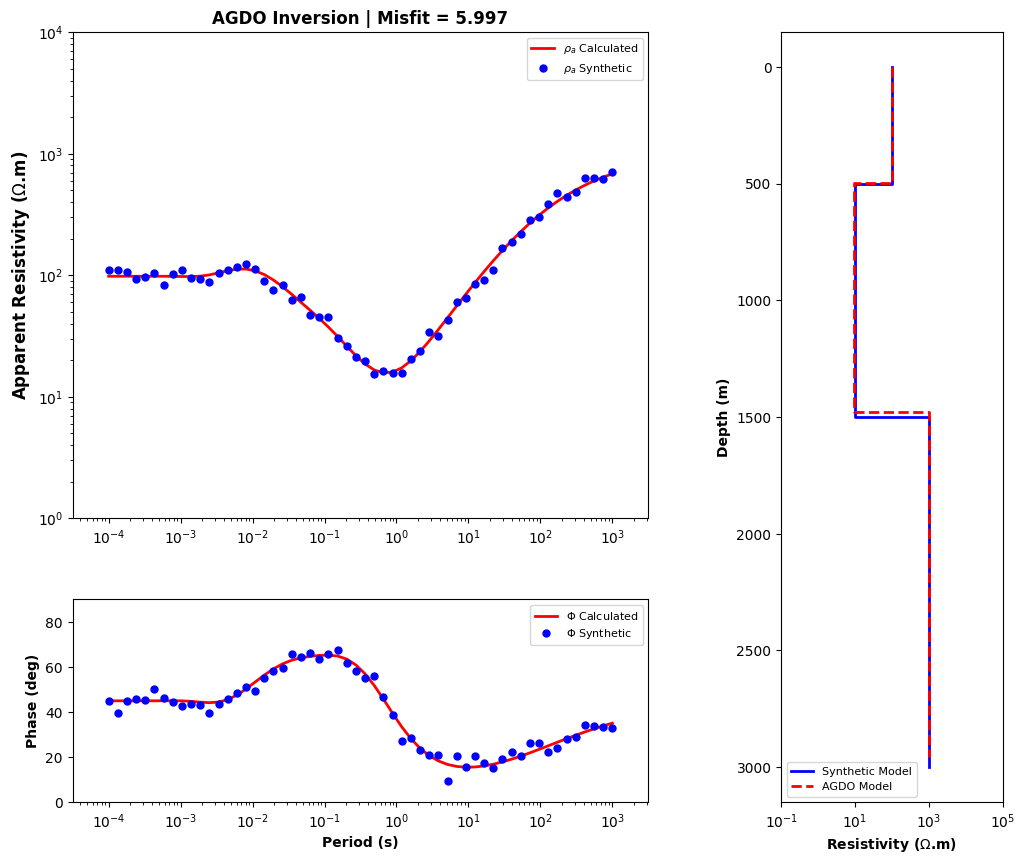

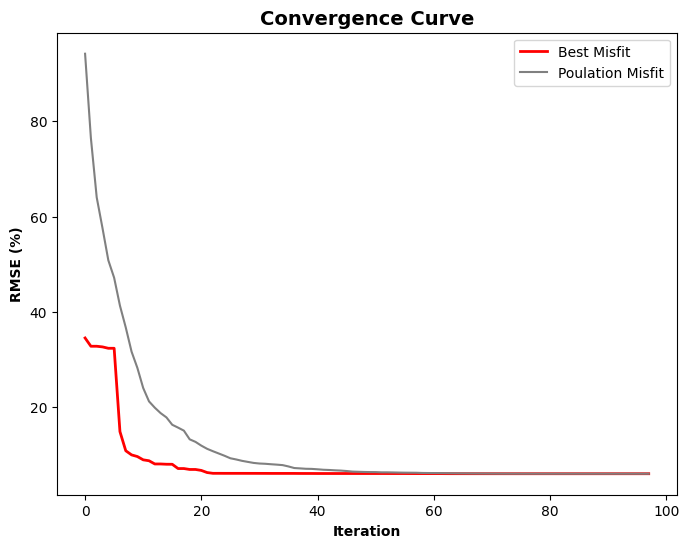

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma


# LOAD DATA
filename = "Data_Synthetic_Model_2.txt"
data = np.loadtxt(filename, skiprows=1)

freq = data[:,0]
rho_obs = data[:,1]
phase_obs = data[:,2]

print("=================================")
print("Synthetic MT data loaded")
print("Total frequencies:",len(freq))
print("=================================")


# FORWARD MT
def MT1D(resistivities, thicknesses, frequency):

    mu = 4*np.pi*1e-7
    w = 2*np.pi*frequency

    rho_app = np.zeros_like(frequency)
    phase = np.zeros_like(frequency)

    for i in range(len(frequency)):

        Z = np.sqrt(1j*w[i]*mu*resistivities[-1])

        for j in range(len(resistivities)-2, -1, -1):

            rho = resistivities[j]
            h = thicknesses[j]

            dj = np.sqrt(1j*w[i]*mu/rho)
            wj = rho*dj
            ej = np.exp(-2*h*dj)

            r = (wj-Z)/(wj+Z)
            Z = wj*((1-r*ej)/(1+r*ej))

        rho_app[i] = (np.abs(Z)**2)/(mu*w[i])
        phase[i] = np.degrees(np.arctan2(Z.imag, Z.real))

    return rho_app, phase


# MISFIT
def misfit(rho_obs, ph_obs, rho_cal, ph_cal):

    nd = len(rho_obs)

    m = np.sqrt((1/nd)*np.sum(
        (np.log10(rho_obs/rho_cal))**2 +
        (np.deg2rad(ph_obs)-np.deg2rad(ph_cal))**2
    ))

    return m*100


# LEVY FLIGHT
def levy(dim, beta=1.5):

    num = gamma(1+beta)*np.sin(np.pi*beta/2)
    den = gamma((1+beta)/2)*beta*2**((beta-1)/2)
    sigma = (num/den)**(1/beta)

    u = np.random.normal(0, sigma, dim)
    v = np.random.normal(0, 1, dim)

    return u/(np.abs(v)**(1/beta))


# AGDO INVERSION
def AGDO_MT(freq, rho_obs, phase_obs,
            npop=120,
            niter=150):

    dim = 5  # 3 resistivity + 2 thickness

    lb = np.array([1,1,1, 10,10])
    ub = np.array([3000,3000,3000, 2000,2000])

    pop = np.random.rand(npop, dim)*(ub-lb)+lb

    m = np.zeros((npop,dim))
    v = np.zeros((npop,dim))

    beta1=0.9
    beta2=0.999
    lr=0.05
    eps=1e-8

    fitness=np.zeros(npop)

    # INITIAL EVALUATION
    for i in range(npop):

        r=pop[i,:3]
        t=pop[i,3:]

        rho,ph=MT1D(r,t,freq)
        fitness[i]=misfit(rho_obs,phase_obs,rho,ph)

    best_idx=np.argmin(fitness)
    best=pop[best_idx].copy()
    best_fit=fitness[best_idx]

    best_curve=[]
    pop_curve=[]

    # Stopping criterion
    tolerance = 1e-3
    patience = 25

    counter = 0
    prev_best = best_fit
    stopped_by_convergence = False

    print("\nStarting AGDO inversion...\n")

    # MAIN LOOP
    for t in range(1,niter+1):

        for i in range(npop):

            omega=np.random.rand()*((t/niter)**2 -2*(t/niter)+0.5)
            alpha=np.cos(1-np.random.rand()*2*np.pi)

            X_new = omega*pop[i] + alpha*pop[i]

            # Gradient interaction
            C=1-np.random.rand()
            P=np.mean(pop,axis=0)-X_new

            grad = best - C*P

            m[i]=beta1*m[i]+(1-beta1)*grad
            v[i]=beta2*v[i]+(1-beta2)*(grad**2)

            mhat=m[i]/(1-beta1**t)
            vhat=v[i]/(1-beta2**t)

            X_new = X_new - lr*mhat/(np.sqrt(vhat)+eps)

            # Levy escape
            if np.random.rand()<0.3:

                delta=np.random.rand()*((t/niter)**2 -2*(t/niter)+1)
                theta=2*t/niter

                X_new = best + levy(dim)*delta*(best-pop[i]*theta)

            X_new=np.clip(X_new,lb,ub)

            r=X_new[:3]
            th=X_new[3:]

            rho,ph=MT1D(r,th,freq)
            f_new=misfit(rho_obs,phase_obs,rho,ph)

            if f_new < fitness[i]:

                pop[i]=X_new
                fitness[i]=f_new

                if f_new < best_fit:
                    best_fit=f_new
                    best=X_new.copy()

        best_curve.append(best_fit)
        pop_curve.append(np.mean(fitness))

        # PATIENCE STOPPING CRITERION

        improvement = abs(prev_best - best_fit)

        if improvement < tolerance:
          counter += 1
        else:
          counter = 0

        prev_best = best_fit

        if counter >= patience:
          stopped_by_convergence = True

          print("\n=================================")
          print("Convergence criterion reached")
          print(f"Stopped at iteration {t}")
          print(f"Best Misfit = {best_fit:.3f}")
          print("=================================")

          break

        if t%10==0:
          print(f"Iteration {t} | Best Misfit = {best_fit:.3f}")

    if not stopped_by_convergence:
        print("Maximum iteration reached")
        print(f"Iteration = {niter}")
        print(f"Best Misfit = {best_fit:.3f}")
        print("=================================")

    return best,best_fit,best_curve,pop_curve


# RUN INVERSION
best,fit,best_curve,pop_curve = AGDO_MT(freq, rho_obs, phase_obs)

print("\n=========== FINAL RESULT ===========")
print("Resistivity (Ohm.m):", best[:3])
print("Thickness (m):", best[3:])
print("Final Misfit:",fit)


# MT RESULT PLOT
rho_cal, phase_cal = MT1D(best[:3], best[3:], freq)

plt.figure(figsize=(12,10))

# Resistivity
plt.subplot(3,3,(1,5))
plt.loglog(1/freq, rho_cal,'r-',1/freq,rho_obs,'ob',
           markersize=5,linewidth=2)
plt.ylabel(r'Apparent Resistivity ($\Omega$.m)',
           fontsize=12,fontweight='bold')
plt.legend([r'$\rho_a$ Calculated',
            r'$\rho_a$ Synthetic'],fontsize=8)
plt.title(f"AGDO Inversion | Misfit = {fit:.3f}",
          fontweight='bold')
plt.xlim(10**-4.5,10**3.5)
plt.ylim(1e0,1e4)


# Phase
plt.subplot(3,3,(7,8))
plt.xlabel('Period (s)',fontweight='bold')
plt.ylabel('Phase (deg)',fontweight='bold')
plt.semilogx(1/freq,phase_cal,'r-',
             1/freq,phase_obs,'ob',
             markersize=5,linewidth=2)
plt.xlim(10**-4.5,10**3.5)
plt.ylim(0,90)
plt.legend([r'$\Phi$ Calculated',
            r'$\Phi$ Synthetic'],fontsize=8)


# MODEL
plt.subplot(3,3,(3,9))

true_res=[100,10,1000]
true_thick=[500,1000]

depth_true=[0]+list(np.cumsum(true_thick))
depth_true.append(depth_true[-1]*2)

plt.step([true_res[0]]+true_res,
         depth_true,
         where='post',
         color='b',
         linewidth=2)

inv_res=best[:3]
inv_thick=best[3:]

depth_inv=[0]+list(np.cumsum(inv_thick))
depth_inv.append(depth_inv[-1]*2)

plt.step([inv_res[0]]+list(inv_res),
         depth_inv,
         where='post',
         color='r',
         linestyle='--',
         linewidth=2)

plt.xscale('log')
plt.xlim(1e-1,1e5)
plt.gca().invert_yaxis()
plt.xlabel('Resistivity ($\Omega$.m)',
           fontweight='bold')
plt.ylabel('Depth (m)',
           fontweight='bold')
plt.legend(['Synthetic Model',
            'AGDO Model'],
            fontsize=8)
plt.subplots_adjust(wspace=0.6,hspace=0.4)
plt.show()


# CONVERGENCE PLOT
plt.figure(figsize=(8,6))
plt.title('Convergence Curve',
          fontsize=14,
          fontweight='bold')
plt.xlabel('Iteration',fontweight='bold')
plt.ylabel('RMSE (%)',fontweight='bold')
plt.plot(best_curve,'-r',linewidth=2)
plt.plot(pop_curve,color='gray',linewidth=1.5)
plt.legend(['Best Misfit',
            'Poulation Misfit'])
plt.show()

# **AGDO ALGORITHM (FIELD DATA)**

In [ ]:
!pip install mtpy

Data loaded: 94

Starting AGDO inversion (5-layer)...

Iteration 10 | Best Misfit = 11.422
Iteration 20 | Best Misfit = 11.108
Iteration 30 | Best Misfit = 10.671
Iteration 40 | Best Misfit = 9.515
Iteration 50 | Best Misfit = 8.200
Iteration 60 | Best Misfit = 8.110
Iteration 70 | Best Misfit = 7.894
Iteration 80 | Best Misfit = 7.894
Iteration 90 | Best Misfit = 7.807
Iteration 100 | Best Misfit = 7.343
Iteration 110 | Best Misfit = 7.221
Iteration 120 | Best Misfit = 7.144
Iteration 130 | Best Misfit = 6.547
Iteration 140 | Best Misfit = 5.898
Iteration 150 | Best Misfit = 5.898
Iteration 160 | Best Misfit = 5.898
Iteration 170 | Best Misfit = 5.481
Iteration 180 | Best Misfit = 5.481

Convergence criterion reached
Stopped at iteration 188
Best Misfit = 5.481

=========== FINAL RESULT ===========
Resistivity (Ohm.m): [  61.41954532 1680.17285335 5835.7518143   807.14571764   31.20630612]
Thickness (m): [   25.34141918  1801.68936784 17217.89355493 22729.95574349]
Final Misfit: 5.480

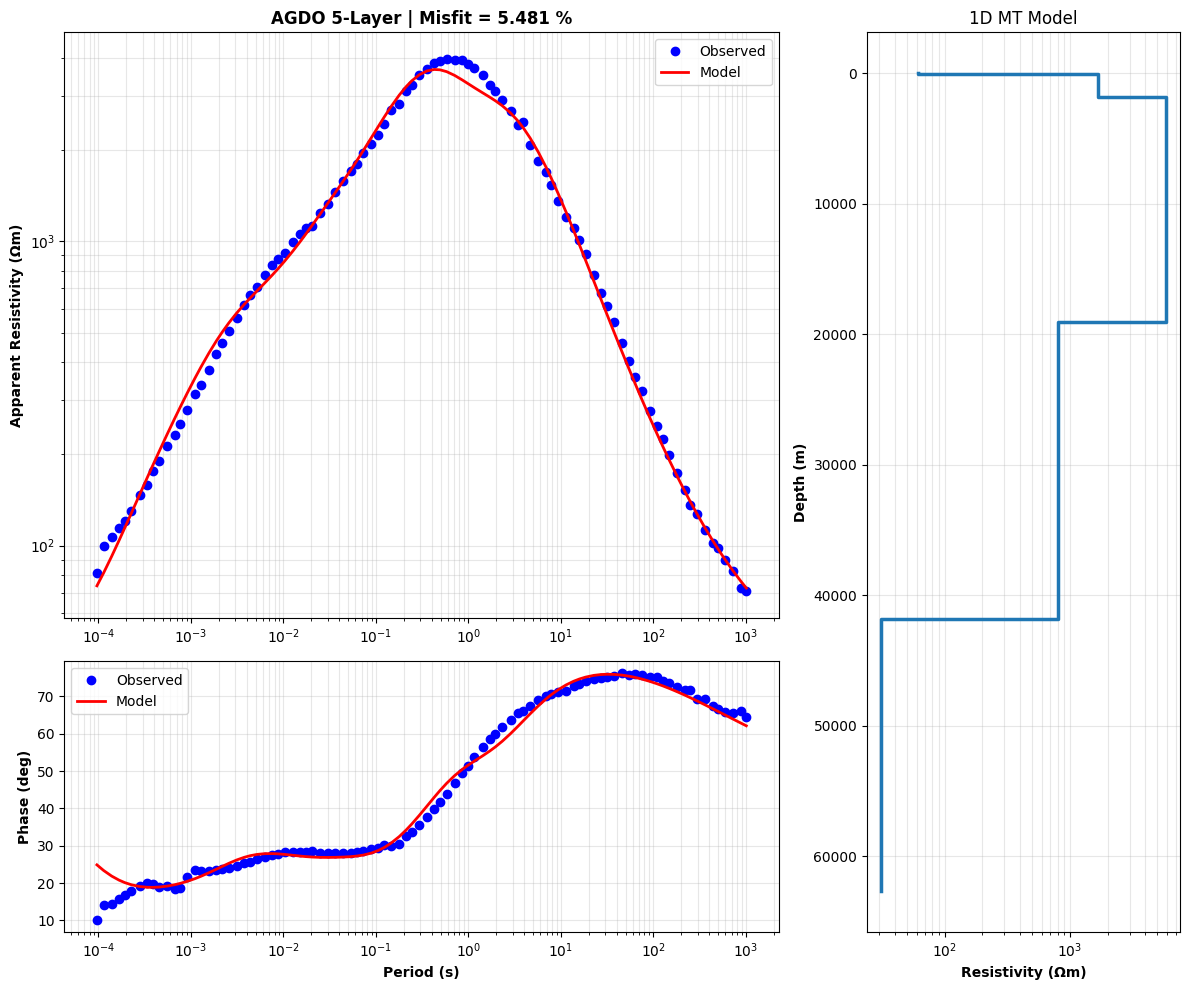

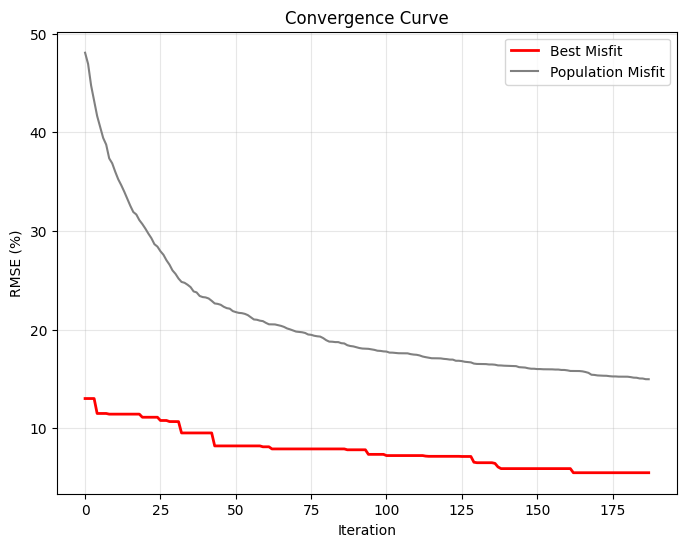

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma


# LOAD DATA LAPANGAN
data = np.loadtxt("datalapanganclcL19S10.txt", skiprows=1)

freq = data[:,0]
rho_obs = data[:,1]
phase_obs = data[:,2]

period = 1/freq

print("Data loaded:", len(freq))

# FORWARD MT 1D
def MT1D(resistivities, thicknesses, frequency):

    mu = 4*np.pi*1e-7
    w = 2*np.pi*frequency

    rho_app = np.zeros_like(frequency)
    phase = np.zeros_like(frequency)

    for i in range(len(frequency)):

        Z = np.sqrt(1j*w[i]*mu*resistivities[-1])

        for j in range(len(resistivities)-2, -1, -1):

            rho = resistivities[j]
            h = thicknesses[j]

            dj = np.sqrt(1j*w[i]*mu/rho)
            wj = rho*dj
            ej = np.exp(-2*h*dj)

            r = (wj-Z)/(wj+Z)
            Z = wj*((1-r*ej)/(1+r*ej))

        rho_app[i] = (np.abs(Z)**2)/(mu*w[i])
        phase[i] = np.degrees(np.arctan2(Z.imag, Z.real))

    return rho_app, phase



# MISFIT
def misfit(rho_obs, ph_obs, rho_cal, ph_cal):

    m = np.sqrt(np.mean(
        (np.log10(rho_obs/rho_cal))**2 +
        (np.deg2rad(ph_obs - ph_cal))**2
    ))

    return m * 100



# LEVY FLIGHT
def levy(dim, beta=1.5):

    num = gamma(1+beta)*np.sin(np.pi*beta/2)
    den = gamma((1+beta)/2)*beta*2**((beta-1)/2)
    sigma = (num/den)**(1/beta)

    u = np.random.normal(0, sigma, dim)
    v = np.random.normal(0, 1, dim)

    return u/(np.abs(v)**(1/beta))



# AGDO
def AGDO_MT(freq, rho_obs, phase_obs,
            npop=200, niter=300):

    dim = 9

    # Bounds
    lb = np.array([ 10, 50, 100, 50, 10, 5, 200, 500, 5000])
    ub = np.array([500, 3000, 20000, 15000, 500, 200, 5000, 20000, 50000])

    pop = np.random.rand(npop, dim)*(ub-lb)+lb

    m = np.zeros((npop,dim))
    v = np.zeros((npop,dim))

    beta1=0.9
    beta2=0.999
    eps=1e-8

    fitness=np.zeros(npop)

    # INITIAL
    for i in range(npop):

        r = pop[i,:5]
        t = pop[i,5:]

        rho,ph = MT1D(r,t,freq)
        fitness[i] = misfit(rho_obs,phase_obs,rho,ph)

    best_idx=np.argmin(fitness)
    best=pop[best_idx].copy()
    best_fit=fitness[best_idx]

    best_curve=[]
    pop_curve=[]

    # Stopping criterion
    tolerance = 1e-3
    patience = 25

    counter = 0
    prev_best = best_fit
    stopped_by_convergence = False

    print("\nStarting AGDO inversion (5-layer)...\n")

    # MAIN LOOP
    for t in range(1,niter+1):

        lr = 0.02*(1-t/niter) + 0.002

        for i in range(npop):

            omega=np.random.rand()*((t/niter)**2 -2*(t/niter)+0.5)
            alpha=np.cos(1-np.random.rand()*2*np.pi)

            X_new = omega*pop[i] + alpha*pop[i]

            C=1-np.random.rand()
            P=np.mean(pop,axis=0)-X_new
            grad = best - C*P

            m[i]=beta1*m[i]+(1-beta1)*grad
            v[i]=beta2*v[i]+(1-beta2)*(grad**2)

            mhat=m[i]/(1-beta1**t)
            vhat=v[i]/(1-beta2**t)

            X_new = X_new - lr*mhat/(np.sqrt(vhat)+eps)

            if np.random.rand()<0.1*(1-t/niter):
                X_new = best + levy(dim)*(best-pop[i])

            X_new=np.clip(X_new,lb,ub)

            r=X_new[:5]
            th=X_new[5:]

            rho,ph = MT1D(r,th,freq)
            f_new = misfit(rho_obs,phase_obs,rho,ph)

            if f_new < fitness[i]:

                pop[i]=X_new
                fitness[i]=f_new

                if f_new < best_fit:
                    best_fit=f_new
                    best=X_new.copy()

        best_curve.append(best_fit)
        pop_curve.append(np.mean(fitness))

        # PATIENCE STOPPING CRITERION

        improvement = abs(prev_best - best_fit)

        if improvement < tolerance:
          counter += 1
        else:
          counter = 0

        prev_best = best_fit

        if counter >= patience:
          stopped_by_convergence = True

          print("\n=================================")
          print("Convergence criterion reached")
          print(f"Stopped at iteration {t}")
          print(f"Best Misfit = {best_fit:.3f}")
          print("=================================")

          break

        if t%10==0:
          print(f"Iteration {t} | Best Misfit = {best_fit:.3f}")

    if not stopped_by_convergence:
        print("Maximum iteration reached")
        print(f"Iteration = {niter}")
        print(f"Best Misfit = {best_fit:.3f}")
        print("=================================")

    return best,best_fit,best_curve,pop_curve



# RUN INVERSION
best, fit, best_curve, pop_curve = AGDO_MT(
    freq, rho_obs, phase_obs)

print("\n=========== FINAL RESULT ===========")
print("Resistivity (Ohm.m):", best[:5])
print("Thickness (m):", best[5:])
print("Final Misfit:", fit)



# FORWARD RESPONSE
rho_cal, phase_cal = MT1D(best[:5], best[5:], freq)


# PLOT RESULT
plt.figure(figsize=(12,10))

# Resistivity
plt.subplot(3,3,(1,5))
plt.loglog(period, rho_obs, 'ob', label='Observed')
plt.loglog(period, rho_cal, 'r-', linewidth=2, label='Model')

plt.ylabel('Apparent Resistivity (Ωm)', fontweight='bold')
plt.title(f"AGDO 5-Layer | Misfit = {fit:.3f} %", fontweight='bold')
plt.legend()
plt.grid(alpha=0.3, which='both')


# Phase
plt.subplot(3,3,(7,8))
plt.semilogx(period, phase_obs, 'ob')
plt.semilogx(period, phase_cal, 'r-', linewidth=2)

plt.xlabel('Period (s)', fontweight='bold')
plt.ylabel('Phase (deg)', fontweight='bold')
plt.legend(['Observed','Model'])
plt.grid(alpha=0.3, which='both')


# MODEL 1D
plt.subplot(3,3,(3,9))

res = best[:5]
thick = best[5:]

depth = [0] + list(np.cumsum(thick))
depth.append(depth[-1]*1.5)

res_plot = [res[0]] + list(res)

plt.step(res_plot, depth,
         where='post',
         linewidth=2.5)

plt.xscale('log')
plt.gca().invert_yaxis()

plt.xlabel('Resistivity (Ωm)', fontweight='bold')
plt.ylabel('Depth (m)', fontweight='bold')
plt.title('1D MT Model')
plt.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()


# Convergence
plt.figure(figsize=(8,6))
plt.plot(best_curve,'-r',linewidth=2,label='Best Misfit')
plt.plot(pop_curve,color='gray',linewidth=1.5,label='Population Misfit')

plt.xlabel('Iteration')
plt.ylabel('RMSE (%)')
plt.title('Convergence Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.show()